# 步骤 02 · 用三个数字代替眼睛

**这一节的产出：表 1（三个指标的数值）+ 图 2（带分散度的对比图）。**

## 上一节留下的问题

图 1 里你做到了一件事、失败了两件事：

- ✅ 外圈故障 —— 数出 21 簇冲击，对上了 BPFO = 105.9 Hz
- ❌ 内圈故障 —— 有尖刺，但节奏是糊的，数不出来
- ❌ 滚珠故障 —— 峰值只有 0.44 g，差点判成正常

而且就算外圈那条，**你是用眼睛数的**。10 秒钟有 1000 多簇，你不可能数完；换一份噪声大的现场数据，簇会挤在一起根本分不开。

**所以第一件事是把眼睛换成数字。** 这一节做的就是：定义几个能自动算出来的量，看它们能走多远。

剧透一下结论，免得你抱错期待：**它们走不了多远，而且失败的方式很有意思。**

---
## 1. 准备

和上一节一样的开头。如果你是新开的 Jupyter，这一格必须先跑。

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import cwru_io

DATA = ROOT / "data"
FIGURES = ROOT / "figures"

normal = cwru_io.load_baseline(DATA / "normal_1hp_98.mat",    name="Healthy")
outer  = cwru_io.load(DATA / "OR007at6_1hp_131.mat", name="Outer race")
inner  = cwru_io.load(DATA / "IR007_1hp_106.mat",    name="Inner race")
ball   = cwru_io.load(DATA / "B007_1hp_119.mat",     name="Ball")

signals = [normal, outer, inner, ball]
print("四条记录就绪，各", len(normal.x), "-", len(outer.x), "个点")

四条记录就绪，各 120976 - 122426 个点


---
## 2. 三个指标分别是什么

这三个量在振动诊断里用了几十年，每个都在回答一个不同的问题。

### ① RMS（均方根，Root Mean Square）—— "抖得有多厉害"

$$\mathrm{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}$$

**为什么不直接求平均？** 因为振动是围着零上下抖的，正负会抵消，平均值永远约等于 0。先平方（全变正数）、再平均、再开方，就得到一个"典型幅度"。

> 这个量你其实很熟：**家里的 220 V 交流电，那个 220 就是 RMS。** 实际电压在 ±311 V 之间摆动，但它做功的效果等同于 220 V 的直流电。RMS 衡量的就是"等效的能量水平"。

**它回答**：这台机器整体振动能量有多大。振动变大通常意味着有问题。

### ② 峭度（Kurtosis）—— "波形里有多少突兀的尖刺"

$$\mathrm{Kurtosis} = \frac{\frac{1}{N}\sum (x_i-\mu)^4}{\sigma^4}$$

注意那个 **4 次方**。这是全部的关键：

- 一个偏离平均值 1 倍标准差的点，贡献 $1^4 = 1$
- 偏离 5 倍的点，贡献 $5^4 = 625$

**所以少数几个极端的尖刺就能把峭度顶起来**，而一大堆温和的波动几乎不影响它。这正是"冲击"的特征。

**它有个非常好用的参照点**：如果信号是纯高斯噪声（完全随机、没有结构），峭度**恰好等于 3**。这是数学上可以证明的。

所以：**峭度 ≈ 3 → 像随机噪声；峭度 >> 3 → 有突出的冲击。**

### ③ 峰值因子（Crest Factor）—— "最高的尖 vs 平常水平"

$$\mathrm{CF} = \frac{\max|x|}{\mathrm{RMS}}$$

最大值除以典型值。一个纯正弦波的峰值因子是 $\sqrt{2} \approx 1.41$；高斯噪声大约 3~4；有强冲击的信号会更高。

**它和峭度在测同一类东西**（信号有多"尖"），但方式不同：峰值因子只看**那一个最高点**，峭度看**所有点的整体分布**。所以峰值因子对单个野点特别敏感 —— 传感器打一个火花，它就废了。

---
## 3. 把公式写成代码

In [12]:
# 算三个时域指标。x 是一维振动数组。
def time_stats(x):
    rms = np.sqrt(np.mean(x ** 2))
    kurt = kurtosis(x, fisher=False)   # fisher=False -> 高斯噪声得 3
    crest = np.abs(x).max() / rms
    return rms, kurt, crest


# 先在已知答案的信号上验证一遍，确认公式没写错
rng = np.random.default_rng(0)
gauss = rng.normal(size=100_000)                       # 纯高斯噪声
sine = np.sin(2 * np.pi * np.arange(100_000) / 100)    # 纯正弦波

print(f"{'':10}{'RMS':>8}{'Kurtosis':>10}{'Crest':>8}")
print(f"{'高斯噪声':10}", "".join(f"{v:>8.2f}" for v in time_stats(gauss)), "  <- 峭度应 ≈ 3")
print(f"{'正弦波':10}", "".join(f"{v:>8.2f}" for v in time_stats(sine)),  "  <- 峰值因子应 ≈ 1.41")

               RMS  Kurtosis   Crest
高斯噪声           1.00    3.02    4.73   <- 峭度应 ≈ 3
正弦波            0.71    1.50    1.41   <- 峰值因子应 ≈ 1.41


**上面这一格做的事叫"用已知答案验证实现"**，值得养成习惯。

我没有直接把函数用在轴承数据上，而是先喂给它两个**我已经知道答案**的信号：高斯噪声的峭度必须是 3，正弦波的峰值因子必须是 √2 ≈ 1.41。对上了，才敢相信它在真实数据上的输出。

> 这是在没有单元测试框架的情况下，最省事的自检方式。你写 C++ 也可以这么干 —— **先用手算得出的例子验证函数，再拿它处理真实数据。** 不然你根本分不清"结果奇怪"是数据的问题还是代码的 bug。

### 一个必须注意的坑：`fisher=False`

`scipy.stats.kurtosis` 默认是 `fisher=True`，返回的是**超值峭度**（excess kurtosis），也就是**已经减掉 3 了**。所以默认情况下高斯噪声得到的是 **0** 而不是 3。

两种约定都对，但**振动诊断的文献几乎都用"高斯 = 3"那一套**。如果你按默认值算完，看到健康轴承是 -0.02，会以为自己算错了。写报告时也一定要注明用的是哪种约定。

---
## 4. 表 1：四种状态的三个指标

In [13]:
print(f"{'状态':<12}{'RMS (g)':>10}{'Kurtosis':>11}{'Crest':>9}")
print("-" * 42)
rows = []
for s in signals:
    r, k, c = time_stats(s.x)
    rows.append((s.name, r, k, c))
    print(f"{s.name:<12}{r:>10.4f}{k:>11.2f}{c:>9.2f}")

状态             RMS (g)   Kurtosis    Crest
------------------------------------------
Healthy         0.0617       2.98     4.58
Outer race      0.5919       7.59     5.26
Inner race      0.2929       5.54     5.40
Ball            0.1391       2.96     4.74


### 读这张表

**发现一：健康轴承的峭度是 2.98 —— 几乎正好是 3。**

这不是巧合，是一个**物理事实的确认**：一个好轴承的振动本质上就是高斯随机噪声，没有任何突出的结构。就像上一节你数出 21 簇一样，这是又一次"理论预测被数据证实"。**值得写进报告。**

**发现二：外圈 7.59、内圈 5.54 —— 峭度确实抓住了冲击。**

比健康的高出一大截，说明波形里有突兀的尖刺。外圈比内圈更高，和图 1 里"外圈的簇更干净利落"一致。

**发现三（最重要）：滚珠故障的峭度是 2.96 —— 比健康的还低。**

**峭度完全漏掉了滚珠故障。** 如果你的诊断规则是"峭度 > 4 就报警"，这个坏轴承会被判成健康，一路开到坏掉为止。

峰值因子也一样（4.74 vs 健康的 4.58，差别在噪声范围内）。**三个指标里有两个对滚珠故障完全失效。**

只有 RMS 抓住了它：0.139 vs 健康的 0.062，两倍多。

---
## 5. 但是 —— 单个数字会骗人

上面每个指标我们只算了**一个数**（整段 10 秒算一次）。这有个问题：

**你不知道这个数稳不稳。** 万一换 10 秒重录，健康的峭度跳到 4.5、外圈掉到 3.2 呢？那"峭度 7.59 > 2.98"就毫无意义了。

**解决办法**：把 10 秒切成很多小段，每段单独算一次，看这些值散得有多开。

段长取 **2048 点**（约 0.17 秒）。这个数字不是随便定的：

- 太短 → 一段里装不下几次冲击，统计量抖得厉害
- 太长 → 段数太少，看不出分布
- 2048 是 2 的 11 次方 —— **后面做 FFT 时 2 的整数次幂效率最高**，现在就用上，省得后面换

0.17 秒里轴转了约 5 圈，外圈冲击约 18 次，够了。

In [18]:
SEG = 2048

# 把信号切成 seg 点一段，每段算一次三个指标。返回 (段数, 3) 的数组。
def segment_stats(x, seg=SEG):
    n = len(x) // seg                      # 丢掉末尾不足一段的零头
    chunks = x[:n * seg].reshape(n, seg)   # 一步切成 n 行
    return np.array([time_stats(c) for c in chunks])


seg_stats = {s.name: segment_stats(s.x) for s in signals}

print(f"{'状态':<12}{'RMS':>16}{'Kurtosis':>17}{'Crest':>15}   段数")
print("-" * 68)
for s in signals:
    v = seg_stats[s.name]
    m, sd = v.mean(axis=0), v.std(axis=0)
    print(f"{s.name:<12}{m[0]:>9.3f} ±{sd[0]:<5.3f}{m[1]:>10.2f} ±{sd[1]:<6.2f}"
          f"{m[2]:>8.2f} ±{sd[2]:<6.2f}   {len(v)}")

状态                       RMS         Kurtosis          Crest   段数
--------------------------------------------------------------------
Healthy         0.062 ±0.001      2.97 ±0.11      3.57 ±0.31     59
Outer race      0.592 ±0.011      7.58 ±0.20      4.96 ±0.16     59
Inner race      0.293 ±0.003      5.54 ±0.28      4.91 ±0.27     59
Ball            0.139 ±0.004      2.96 ±0.14      3.50 ±0.32     59


`reshape(n, seg)` 是 NumPy 里很常用的一招：把一个长度 120832 的一维数组，**不复制数据**，直接看成 59 行 × 2048 列的二维数组。每一行就是一段。

> `±` 后面是**标准差**（standard deviation），衡量这 59 个值散得有多开。标准差小 = 很稳定。

看结果：所有指标的标准差都很小（峭度的标准差只有 0.1~0.3）。**说明这些值是可靠的，不是运气。**

但这也让下一个结论更扎实 —— 我们来画图看。

---
## 6. 图 2：三个指标的对比

每个指标画一个子图。柱子是 59 段的平均值，**上面那些小点是每一段各自的值** —— 点散得越开，说明这个指标越不稳定。

把散点画出来而不是只画柱子，是为了让"两类到底分不分得开"一目了然。只画柱子的话，你看到两根不一样高就以为能区分，实际上可能它们的散点完全叠在一起。

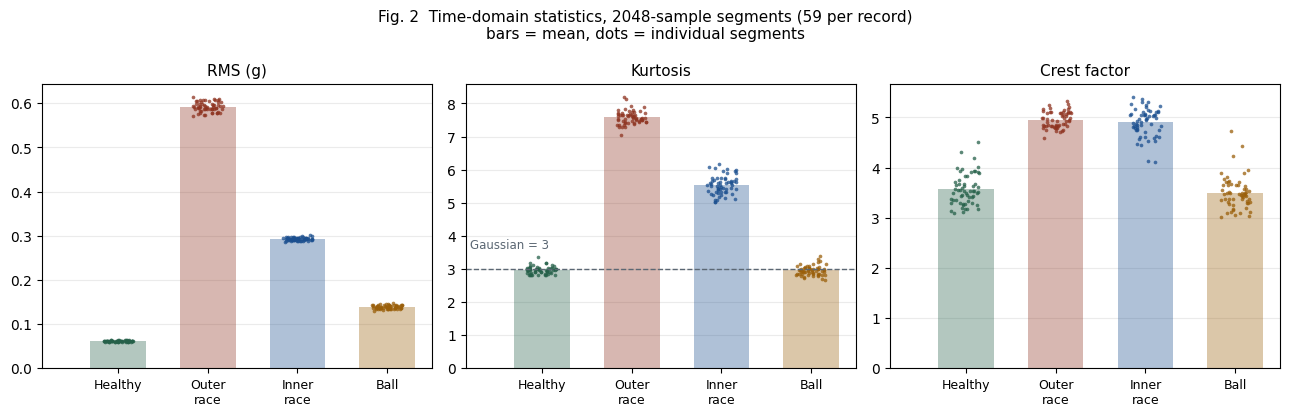

原始:   ['0.592', '7.595', '5.258']
打乱后: ['0.592', '7.595', '5.258']


In [20]:
COLORS = {"Healthy": "#256049", "Outer race": "#8E3320",
          "Inner race": "#1B4F8F", "Ball": "#9A5F0A"}
METRICS = ["RMS (g)", "Kurtosis", "Crest factor"]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
jitter = np.random.default_rng(1)

for j, (ax, metric) in enumerate(zip(axes, METRICS)):
    for i, s in enumerate(signals):
        vals = seg_stats[s.name][:, j]
        ax.bar(i, vals.mean(), color=COLORS[s.name], alpha=0.35, width=0.62)
        # 每段的值画成散点，横向随机抖开一点免得叠在一条线上
        ax.scatter(i + jitter.uniform(-0.17, 0.17, len(vals)), vals,
                   s=7, color=COLORS[s.name], alpha=0.75, linewidths=0)
    ax.set_xticks(range(4))
    ax.set_xticklabels([s.name.replace(" ", "\n") for s in signals], fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_xlim(-0.85, 3.5)   # 左边留白，给下面那条参照线的标注让位

# 在峭度子图上标出"高斯噪声 = 3"这条参照线
axes[1].axhline(3, color="#5B6773", linestyle="--", linewidth=1)
axes[1].text(-0.8, 3.62, "Gaussian = 3", fontsize=8.5, color="#5B6773", ha="left")

fig.suptitle("Fig. 2  Time-domain statistics, 2048-sample segments (59 per record)\n"
             "bars = mean, dots = individual segments", fontsize=11)
fig.tight_layout()
plt.show()
shuffled = np.random.default_rng(2).permutation(outer.x)
print("原始:  ", [f"{v:.3f}" for v in time_stats(outer.x)])
print("打乱后:", [f"{v:.3f}" for v in time_stats(shuffled)])

---
## 7. 看图 —— 这一节真正的结论

### RMS 子图：四类分得干干净净

散点完全不重叠，从 Healthy 到 Outer 一路升高。看起来很成功。

**但 RMS 有个致命的实用问题：它没有绝对标准。**

0.139 g 是"坏"吗？只有在你知道这台机器健康时是 0.062 g 的前提下才能这么说。**换一台更大的电机、换个转速、换个安装方式，健康值可能就是 0.3 g。** 现场诊断时你往往没有这台机器的健康基线。

而且 RMS 升高的原因太多了 —— 地脚螺栓松了、联轴器不对中、转子不平衡，全都会让 RMS 上升。**它告诉你"有事发生"，不告诉你是什么事。**

### 峭度子图：三个发现

**① 健康的那簇点紧紧贴在虚线（=3）上。** 又一次确认：好轴承的振动就是高斯噪声。

**② 外圈（7.6）和内圈（5.5）明显抬起来了**，而且两簇点不重叠。

**③ 滚珠那簇点，和健康那簇完全重合。**

分段的范围是：健康 2.81~3.37，滚珠 2.67~3.40。**彻底重叠，没有任何阈值能把它们分开。**

### 峰值因子子图：和峭度一个毛病，而且更差

滚珠和健康同样重合，外圈和内圈之间（4.96 vs 4.91）也几乎没有差别 —— **连"哪种故障"的一点线索都不给。**

> 注意一个细节：外圈的峭度（7.0~8.2）和内圈的（5.0~6.2）在这份数据上确实不重叠。但**不要因此以为峭度能区分故障类型**。这个高低顺序没有任何物理依据 —— 它取决于这两个坑的大小、位置、负载，换一组数据顺序完全可能反过来。**碰巧分开 ≠ 能用来诊断。**

---
## 8. 所以我们撞到了第二堵墙

把这一节和上一节放在一起：

| 想知道 | 眼睛看波形 | 三个统计量 |
|---|---|---|
| 有没有问题 | 外圈能、滚珠不能 | RMS 能，峭度和峰值因子**漏掉滚珠** |
| 是哪种问题 | 不能 | **完全不能** |
| 能自动化 | 不能 | ✅ 能，这是唯一的进步 |

**唯一的进步是"自动化"** —— 现在是机器在算，不是你在数。但能力上几乎没长进。

### 为什么它们注定不行

因为这三个量都**只看"幅度的分布"，完全丢掉了"时间顺序"**。

你把 12 万个数字随机打乱顺序，RMS、峭度、峰值因子**一个都不变**。

而"外圈坏了"这个信息**恰恰只存在于顺序里** —— 是"每秒 105.9 次"这个节奏。打乱之后节奏没了，可这三个数字毫无察觉。

> 这句话值得记住：**这三个指标对信号的排列顺序完全不敏感，而故障类型的信息只藏在顺序里。**
>
> 所以不是"它们做得不够好"，是**它们在原理上就不可能回答这个问题**。换再多的统计量（偏度、方差、能量熵……）都一样，只要它是"幅度分布"类的量，就必然丢掉节奏。

**要拿到节奏信息，只有一条路：换一个能看见频率的工具。**

那就是下一节的 FFT。

---
## 9. 保存

In [6]:
FIGURES.mkdir(exist_ok=True)
out = FIGURES / "fig02_time_stats.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("已保存:", out)

# 顺便把表 1 存成文本，写报告时直接抄
table = FIGURES / "table01_time_stats.txt"
with open(table, "w", encoding="utf-8") as f:
    f.write(f"{'Condition':<14}{'RMS (g)':>10}{'Kurtosis':>11}{'Crest':>9}\n")
    f.write("-" * 44 + "\n")
    for name, r, k, c in rows:
        f.write(f"{name:<14}{r:>10.4f}{k:>11.2f}{c:>9.2f}\n")
    f.write("\nKurtosis uses the Pearson convention (Gaussian = 3).\n")
    f.write(f"Whole record, {cwru_io.FS} Hz, 1 hp load.\n")
print("已保存:", table)
print()
print(table.read_text(encoding="utf-8"))

已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\fig02_time_stats.png
已保存: D:\废弃学习资料\老子有用\文书文件\bearing-diagnosis\figures\table01_time_stats.txt

Condition        RMS (g)   Kurtosis    Crest
--------------------------------------------
Healthy           0.0617       2.98     4.58
Outer race        0.5919       7.59     5.26
Inner race        0.2929       5.54     5.40
Ball              0.1391       2.96     4.74

Kurtosis uses the Pearson convention (Gaussian = 3).
Whole record, 12000 Hz, 1 hp load.



---
## 10. 自己动手

**练习 1.** 把 `time_stats` 里的 `fisher=False` 改成 `True`，重跑第 4 节。所有峭度会变成什么？和原来差多少？（这就是那个约定的坑，亲手踩一次记得牢。）改完记得改回来。

**练习 2（重要，验证第 8 节那个论断）.** 把信号随机打乱顺序，看三个指标变不变：

```python
shuffled = np.random.default_rng(2).permutation(outer.x)
print("原始:  ", [f"{v:.3f}" for v in time_stats(outer.x)])
print("打乱后:", [f"{v:.3f}" for v in time_stats(shuffled)])
```

三个数字应该几乎一模一样（峰值因子完全相同，因为最大值和 RMS 都不随顺序变）。**但打乱之后，这个信号里已经没有任何轴承故障信息了** —— 冲击的节奏彻底毁了。

这就是第 8 节那句话的实验证明：**这三个指标看不见节奏。**

**练习 3.** 把 `SEG` 从 2048 改成 512 和 8192，各跑一次第 5 节。段越短，散点散得越开还是越紧？想一想为什么。

---
## 小结

| 做了 | 结论 |
|---|---|
| 定义 RMS / 峭度 / 峰值因子，并用已知信号验证 | 实现正确 |
| 整段计算（表 1） | 健康峭度 = 2.98 ≈ 3，符合高斯理论 |
| 分段计算（图 2） | 值很稳定，标准差很小，结论可信 |
| 能否检出故障 | RMS 可以；**峭度和峰值因子漏掉滚珠故障** |
| 能否区分故障类型 | **完全不能，而且原理上不可能** |

**下一步（步骤 03）**：第一次做 FFT，把信号从"时域"搬到"频域"。我们会直接去 105.9 Hz 看那根柱子 —— 然后发现**那里什么都没有**。

那将是这个项目里最重要的一次失败。